## <font color = '#004D9E'> Propuesta de Cálculo de Tamaño Muestral para Experimentos A/B con Segmentación Categórica

**Introducción:**

En el análisis de experimentos A/B, una preocupación frecuente es garantizar que los grupos control y tratamiento sean estadísticamente representativos, especialmente cuando la población objetivo está segmentada en categorías mutuamente excluyentes (por ejemplo, grupos demográficos, niveles de engagement o tipos de comportamiento).

La siguiente es una propuesta de muestreo para datos categóricos disjuntos, donde la población está particionada en 5 segmentos. Calcularemos un volumen de muestra representativo modelando cada segmento como una variable Bernoulli, determinando el tamaño muestral necesario para estimar sus proporciones poblacionales con precisión controlada, y seleccionando el volumen máximo para asegurar representatividad simultánea en todos los subgrupos.

**Análisis Preliminar:**

Se carga el insumo que ocuparemos, el cual contiene solo un identificador único (Id) para cada usuario y el segmento al que pertenece el mismo. El insumo contiene información de 487,002 clientes, la cual será nuestra población total.

In [1]:
import pandas as pd

data = pd.read_csv("Data_Clientes.csv")
data.Segmento_Cliente.value_counts().reset_index().sort_values('Segmento_Cliente')

,Segmento_Cliente,count
4,Segmento A,37137
3,Segmento B,68185
1,Segmento C,103050
2,Segmento D,75902
0,Segmento E,202728


Dado que los segmentos que componen la población son disjuntos entre sí, un usuario cualquiera de la población puede pertenecer a uno y sólo uno de los segmentos. Formalmente, para el segmento k-ésimo ($Seg_k$), definimos la variable aleatoria indicadora:

$$
X^k = 
\begin{cases} 
1 & \text{si el usuario } \in Seg_k \\
0 & \text{en caso contrario}
\end{cases}
$$

La probabilidad de pertenencia al segmento viene dada por:

$$
\mathbb{P}(X^k = 1) = p_k = \frac{|Seg_k|}{|Población|}
$$

donde $|\cdot|$ denota la cardinalidad del conjunto *(finito)*.

Así, para una muestra de tamaño $n < |Seg_k|$, definimos el estimador:

$$
\hat{p}_k = \frac{1}{n} \sum_{i=1}^{n} X_i^k
$$

Por el Teorema del Límite Central, cuando $n$ es suficientemente grande *(mayor que 30)*:

$$
\hat{p}_k \dot{\sim} \mathcal{N}\left(p_k, \sqrt{\frac{p_k(1-p_k)}{n}}\right)
$$

y dado que la proporción poblacional $p_k$ es conocida *(calculable mas bien)*, podemos construir el intervalo de confianza para nuestra estimación muestral de $\hat{p}_k$ para un nivel de confianza $1-\alpha$ comos sigue:

$$
IC_{1-\alpha}(p_k) = \hat{p}_k \pm z_{\alpha/2} \cdot \displaystyle{ \sqrt{\frac{p_k(1-p_k)}{n}}}
$$

donde $z_{\alpha/2}$ es el cuantil de la distribución normal estándar y la amplitud máxima del intervalo (*que tanto se abre el intervalo de confianza*) es:

$$
n_k = \left( \frac{z_{1-\alpha/2}}{E} \right)^2 p_k(1-p_k)
$$

Por lo que finimos la función *"calcular_nk"* para obtener el $n_k$ de cada uno de los segmentos de nuestra población:

In [2]:
from scipy.stats import norm
import numpy as np

def calcular_nk(p_k, margen_error=0.05, confianza=0.95):
    """
    Calcula el tamaño muestral requerido para estimar la proporción de un segmento.
    
    Parámetros:
    -----------
    p_k : float
        Proporción poblacional conocida del segmento (0 < p_k < 1)
    margen_error : float, opcional
        Error máximo tolerable (por defecto 0.05)
    confianza : float, opcional
        Nivel de confianza (por defecto 0.95)
    
    Retorna:
    --------
    int
        Tamaño muestral mínimo requerido
    """
    alpha = 1 - confianza
    z = norm.ppf(1 - alpha/2)  # Valor crítico bilateral
    
    # Cálculo del tamaño muestral
    n = (z**2 * p_k * (1 - p_k)) / (margen_error**2)
    
    return int(np.ceil(n))  # Redondeo al entero superior

Generamos un dataframe con los volumenes obtenidos,

In [3]:
proporciones = data['Segmento_Cliente'].value_counts(normalize=True)
margen_error = 0.005  # 0.5% de margen de error
confianza = 0.95

# Dataframe de resultados
resultados = pd.DataFrame({
    'segmento': proporciones.index,
    'proporcion_poblacional': proporciones.values,
    'tamaño_muestra': [calcular_nk(p_k, margen_error, confianza) 
                      for p_k in proporciones.values]
}).sort_values('segmento', ascending=False)

resultados

,segmento,proporcion_poblacional,tamaño_muestra
0,Segmento E,0.416278,37338
2,Segmento D,0.155856,20217
1,Segmento C,0.211601,25635
3,Segmento B,0.140010,18502
4,Segmento A,0.076256,10824


**¿Cuál $n_k$ elegir?**

El cálculo individual de los $n_k$ para cada segmento garantiza que la estimación de $p_k$ cumpla con los requisitos de precisión *(margen de error $E$ y confianza $1-\alpha$)* para cada segmento por separado. Sin embargo, para asegurar que todos los segmentos simultáneamente satisfagan estos criterios, adoptamos un enfoque conservador eligiendo a el volumen $n^*$ definido como:

$$
n^* = \max_{k \in \{A,B,\cdots,E\}} n_k
$$

In [4]:
resultados.tamaño_muestra.max()

np.int64(37338)

**Validación mediante Bootstrap**

Para confirmar la robustez de $n^*$, realizamos un remuestreo estadístico (Bootstrap) con la siguiente lógica:

- **1.- Simulación:**
    - Generamos 1000 muestras aleatorias de tamaño $n^*$ sin reemplazo desde la población original.
    - Calculamos las proporciones de cada segmento en cada muestra.
    
- **2.- Métricas de evaluación:**
    -  Se calcula la diferencia absoluta promedio entre proporciones muestrales y reales (idealmente cercana a 0).
    - Se corrobora que la amplitud del intervalo de confianza del 95% para cada proporción sea del $E$ seleccionado.
    
- **3.- Resultados observados: (ver dataframe output)**
    - Las diferencias absolutas son mínimas *($\sim 10^{-5}$)* confirmando que $n^*$ preserva las proporciones reales.
    - Todos los intervalos de confianza (IC) contienen las proporciones reales, validando la cobertura del 95%

In [5]:
import sys
sys.path.append("/home/jupyter/10050375_Edu'") 
from ToolBox_Promos import Bootstrap  # Herramienta propia para remuestreo

Bootstrap(
    data,                           # DataFrame original
    'Segmento_Cliente',             # Columna categórica
    resultados.tamaño_muestra.max(), # n^* (tamaño muestral final)
    1000,                           # Número de simulaciones
    "resumen_remuestreo",           # Nombre del output
    True                            # Calcula ICs
)

resumen_remuestreo

Simulando muestras: 100%|██████████| 1000/1000 [00:18<00:00, 53.23muestra/s]


 LISTO !!!!


,Proporción_Real,Proporción_Muestral_Promedio,Diferencia_Absoluta,IC_95_inferior,IC_95_superior
Segmento_Cliente,,,,,
Segmento A,0.076256,0.076249,0.000007,0.073437,0.078715
Segmento B,0.140010,0.140025,0.000015,0.136563,0.143500
Segmento C,0.211601,0.211604,0.000003,0.207322,0.215492
Segmento D,0.155856,0.155945,0.000089,0.152256,0.159489
Segmento E,0.416278,0.416177,0.000101,0.411323,0.420992


**Interpretación Gráfica de laValidación mediante Bootstrap**

Por último, la siguiente gráfica compara las proporciones estimadas mediante el Bootstrap (puntos azules con intervalos del 95%) frente a las proporciones reales (líneas punteadas rojas). La perfecta alineación entre ambos elementos confirma que las estimaciones son precisas, mientras que los intervalos estrechos demuestran que el tamaño muestral $n^*$ garantiza el margen de error requerido. Esta visualización valida empíricamente la efectividad del método propuesto.

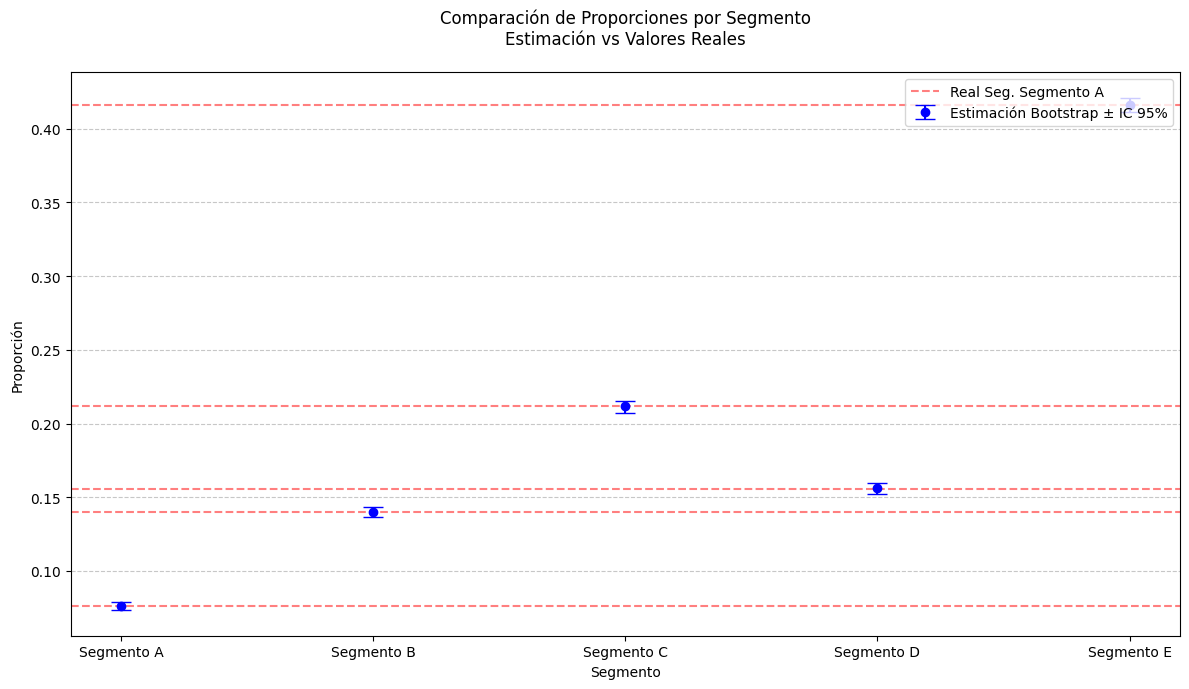

In [6]:
import matplotlib.pyplot as plt

resumen_remuestreo.reset_index(inplace=True)
resumen_remuestreo = resumen_remuestreo.sort_values('Segmento_Cliente')

plt.figure(figsize=(12, 7))

plt.errorbar(
    x=resumen_remuestreo['Segmento_Cliente'],
    y=resumen_remuestreo['Proporción_Muestral_Promedio'],
    yerr=[
        resumen_remuestreo['Proporción_Muestral_Promedio'] - resumen_remuestreo['IC_95_inferior'],
        resumen_remuestreo['IC_95_superior'] - resumen_remuestreo['Proporción_Muestral_Promedio']
    ],
    fmt='o',
    capsize=7,
    color='blue',
    label='Estimación Bootstrap ± IC 95%'
)

for _, row in resumen_remuestreo.iterrows():
    plt.axhline(y=row['Proporción_Real'], 
                color='red', 
                linestyle='--', 
                alpha=0.5,
                label=f'Real Seg. {row["Segmento_Cliente"]}' if _ == 0 else "")

plt.title('Comparación de Proporciones por Segmento\nEstimación vs Valores Reales', pad=20)
plt.xlabel('Segmento')
plt.ylabel('Proporción')
plt.xticks(resumen_remuestreo['Segmento_Cliente']) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.tight_layout()
plt.show()

**Conclusión:**

Este estudio demuestra que el método propuesto -basado en modelar cada segmento como una distribución Bernoulli y seleccionar el tamaño muestral máximo requerido- garantiza efectivamente la representatividad estadística de todos los subgrupos poblacionales. La validación mediante Bootstrap confirma que las proporciones estimadas coinciden precisamente con los valores reales de la población, mientras que los intervalos de confianza estrechos verifican que se alcanza la precisión deseada. El enfoque conservador de utilizar $n^* = \max_k\{n_k\}$ asegura que incluso los segmentos minoritarios estén adecuadamente representados, permitiendo generalizar con confianza los resultados del experimento a toda la población y sus subgrupos estratégicos. Este marco metodológico proporciona así una solución robusta para el diseño de experimentos A/B en contextos con segmentación categórica.